# 📊 Laboratório de Data Science: O Raio-X Visual
**Disciplina:** Ciência de Dados
**Prof:** Rafael Duarte
**Instruções:** Clique em `Arquivo > Salvar uma cópia no Drive` antes de começar a codificar.

In [ ]:
import pandas as pd
import numpy as np
import math
import seaborn as sns
import matplotlib.pyplot as plt

# 1. A Semente Mágica: Trava a aleatoriedade (todos terão a mesma base)
np.random.seed(42)

# 2. O Miolo da População: 8.000 salários (Média 4k, Desvio 800)
salarios_normais = np.random.normal(loc=4000, scale=800, size=8000)

# 3. As Anomalias (Outliers para estourar as Cercas)
outliers_baixos = np.random.uniform(500, 900, size=50)       # 50 Estagiários
outliers_altos = np.random.uniform(25000, 150000, size=15)   # 15 CEOs/Diretores

# 4. Consolidando o DataFrame
todos_salarios = np.concatenate([salarios_normais, outliers_baixos, outliers_altos])
df = pd.DataFrame({'salario': todos_salarios})

# Limpeza e formatação
df['salario'] = df['salario'].clip(lower=500).round(2)

print(f"Base gerada com sucesso! Total de registros: {len(df)}")

Base gerada com sucesso! Total de registros: 8065


### 🎯 Desafio 1: O Raio-X Numérico
Use a função do Pandas que exibe todas as métricas descritivas da coluna `salario`. Anote os valores do Q1 (25%) e Q3 (75%).

In [ ]:
metricas_salario = df['salario'].describe()

print(metricas_salario)

: 

### 🎯 Desafio 2: A Matemática da Anomalia
Com base nos valores de Q1 e Q3 que você encontrou acima:
1. Calcule o IQR (Q3 - Q1).
2. Calcule o Limite Superior da Cerca Matemática ( Q3 + 1.5 * IQR ).
Imprima os dois valores na tela.

In [ ]:
q1 = 3443.88
q3 = 4537.91

# Calcule o IQR e o Limite Superior abaixo:
iqr = q3 - q1
limite_suprior = q3 + (1.5 * iqr)

print(f"IQR = {iqr:.2f}\nLimite Superior = {limite_suprior:.2f}")

IQR = 1094.03
Limite Superior = 6178.95


### 🎯 Desafio 3: A Prova Visual (Boxplot)
Chega de números. Use a biblioteca `seaborn` (apelidada de `sns`) para desenhar o Boxplot da coluna `salario`. Você verá o Limite Superior que acabou de calcular sendo desenhado na tela, com os outliers explodindo para cima.

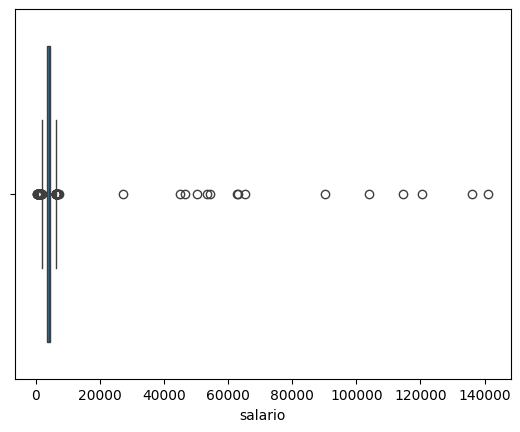

In [ ]:
sns.boxplot(x=df['salario'])

# plt.xlim(0, 10000)

plt.show()

### 🎯 Desafio 4: A Regra de Sturges e o Histograma
Nós temos 8.065 registros. Usando a fórmula de Sturges ($k = 1 + 3.322 \times \log_{10} N$), calcule quantos "baldes" (bins) devemos usar. Em seguida, desenhe o `histplot` com o Seaborn passando esse valor para o parâmetro `bins`.

O número de bins calculado pela Regra de Sturges é: 14


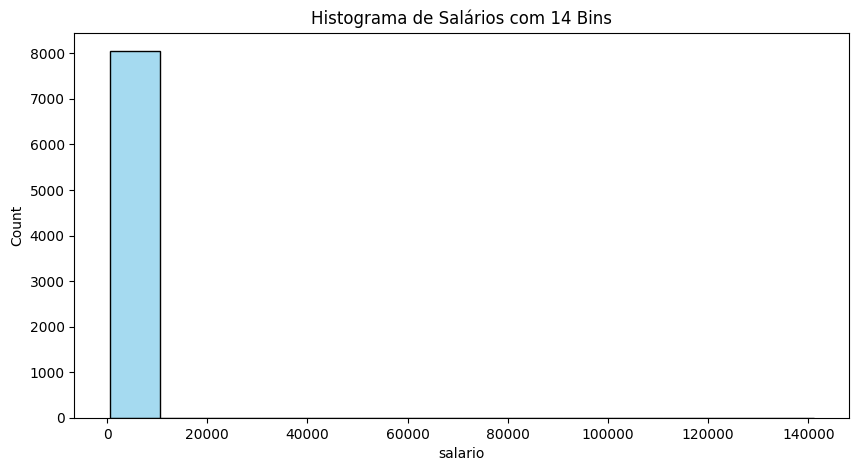

In [ ]:
N = len(df)

k_matematico = 1 + 3.322 * math.log10(N)

k_bins = round(k_matematico)
print(f"O número de bins calculado pela Regra de Sturges é: {k_bins}")

plt.figure(figsize=(10, 5))

sns.histplot(x=df['salario'], bins=k_bins, color='skyblue')

plt.title(f'Histograma de Salários com {k_bins} Bins')

plt.show()

### 🎯 Desafio 5 (BOSS): A Cirurgia de Dados
Você descobriu que o Limite Superior aceitável é aproximadamente R$ 6.300. Usando filtros do Pandas, crie um novo DataFrame chamado `df_limpo` que exclua todos os salários maiores que esse limite. Imprima o tamanho da nova base.

In [ ]:
limite_superior = 6300

df_limpo = df[df['salario'] <= limite_superior]

tamanho_novo = len(df_limpo)

print(f"O tamanho da nova base df_limpo é: {tamanho_novo} registros.")

O tamanho da nova base df_limpo é: 8030 registros.
